In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
adult=pd.read_csv("/content/adult_dataset.csv")
adult.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40.0,NaN,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K


In [3]:
adult.isnull().sum()

,0
age,2442
workclass,3362
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,3357
relationship,0
race,0
sex,0


In [4]:
adult.shape

(48842, 15)

In [5]:
adult.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             46400 non-null  float64
 1   workclass       45480 non-null  object 
 2   fnlwgt          48842 non-null  int64  
 3   education       48842 non-null  object 
 4   education-num   48842 non-null  int64  
 5   marital-status  48842 non-null  object 
 6   occupation      45485 non-null  object 
 7   relationship    48842 non-null  object 
 8   race            48842 non-null  object 
 9   sex             48842 non-null  object 
 10  capital-gain    48842 non-null  int64  
 11  capital-loss    48842 non-null  int64  
 12  hours-per-week  46400 non-null  float64
 13  native-country  46137 non-null  object 
 14  income          48842 non-null  object 
dtypes: float64(2), int64(4), object(9)
memory usage: 5.6+ MB


In [6]:
adult.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,46400.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,46400.000000
mean,38.679116,1.896641e+05,10.078089,1079.067626,87.502314,40.448599
std,13.952954,1.056040e+05,2.570973,7452.019058,403.004552,12.646992
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,255.000000,1.490400e+06,16.000000,99999.000000,4356.000000,250.000000


In [7]:
adult.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income'],
      dtype='object')

In [8]:
adult.replace('?', np.nan, inplace=True)

In [9]:
adult.isnull().sum()

,0
age,2442
workclass,5125
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,5115
relationship,0
race,0
sex,0


In [10]:
adult["occupation"].value_counts()

,count
occupation,
Prof-specialty,5854
Craft-repair,5791
Exec-managerial,5771
Adm-clerical,5329
Sales,5231
Other-service,4657
Machine-op-inspct,2874
Transport-moving,2238
Handlers-cleaners,1977


In [11]:
adult.duplicated().sum()

np.int64(16)

In [12]:
adult.drop_duplicates(inplace=True)

In [13]:
adult.shape

(48826, 15)

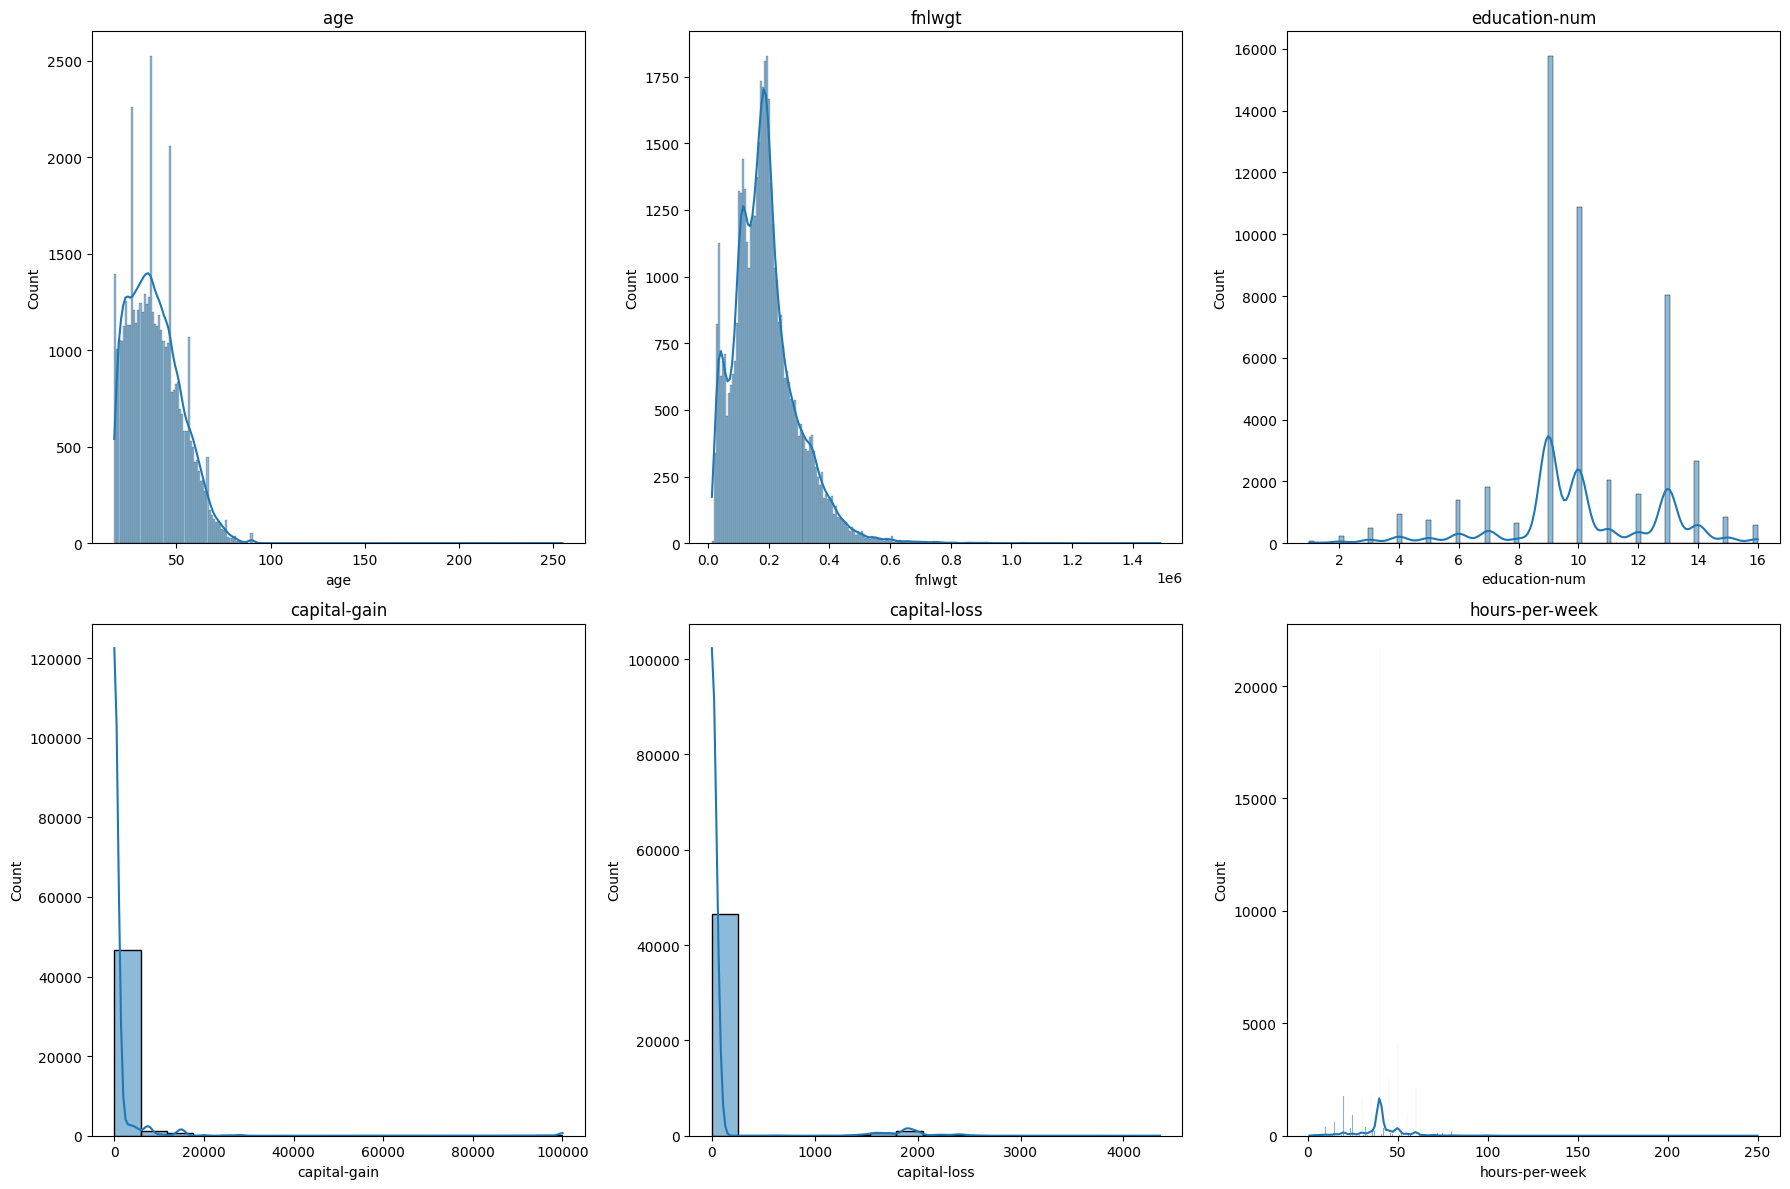

In [14]:
num_cols = adult.select_dtypes(include=['int64','float64']).columns

plt.figure(figsize=(18,12))

for i, col in enumerate(num_cols):
    plt.subplot(2,3,i+1)
    sns.histplot(adult[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

In [15]:
adult["age"].value_counts()

,count
age,
33.0,1289
36.0,1289
35.0,1275
23.0,1257
31.0,1245
...,...
225.0,1
86.0,1
140.0,1


In [16]:
adult.isnull().mean()*100

,0
age,5.001434
workclass,10.496457
fnlwgt,0.000000
education,0.000000
education-num,0.000000
marital-status,0.000000
occupation,10.475976
relationship,0.000000
race,0.000000
sex,0.000000


In [17]:
num_cols = adult.select_dtypes(include=['int64', 'float64']).columns
num_cols

Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')

In [18]:
for col in num_cols:
    adult[col] = adult[col].fillna(adult[col].median())

In [19]:
adult[num_cols].isnull().sum()

,0
age,0
fnlwgt,0
education-num,0
capital-gain,0
capital-loss,0
hours-per-week,0


In [20]:
cat_cols = adult.select_dtypes(include='object').columns

for col in cat_cols:
    adult[col] = adult[col].fillna(adult[col].mode()[0])

In [21]:
adult[cat_cols].isnull().sum()

,0
workclass,0
education,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0
native-country,0
income,0


In [22]:
adult.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


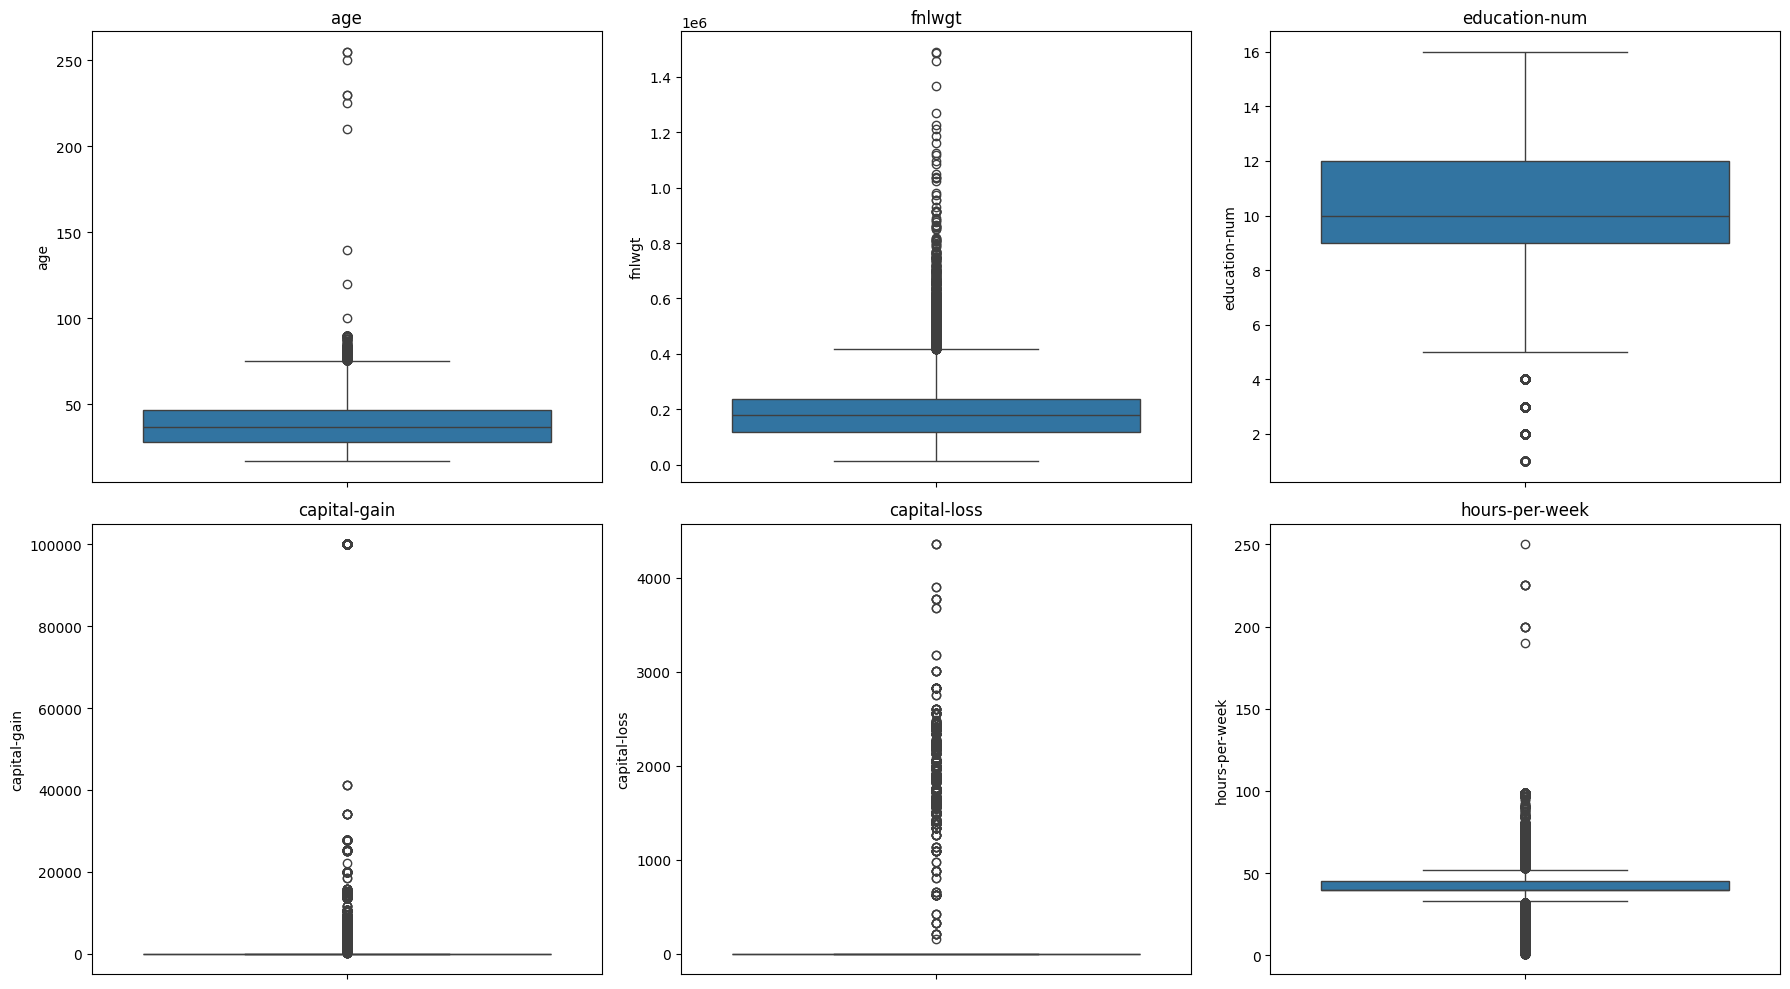

In [23]:
num_cols = adult.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(18,10))

for i, col in enumerate(num_cols):
    plt.subplot(2, 3, i+1)
    sns.boxplot(y=adult[col])
    plt.title(col)

plt.tight_layout()
plt.show()

Treating outliers

In [24]:
num_cols = adult.select_dtypes(include=['int64','float64']).columns

for col in num_cols:

    Q1 = adult[col].quantile(0.25)
    Q3 = adult[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    adult[col] = adult[col].clip(lower, upper)

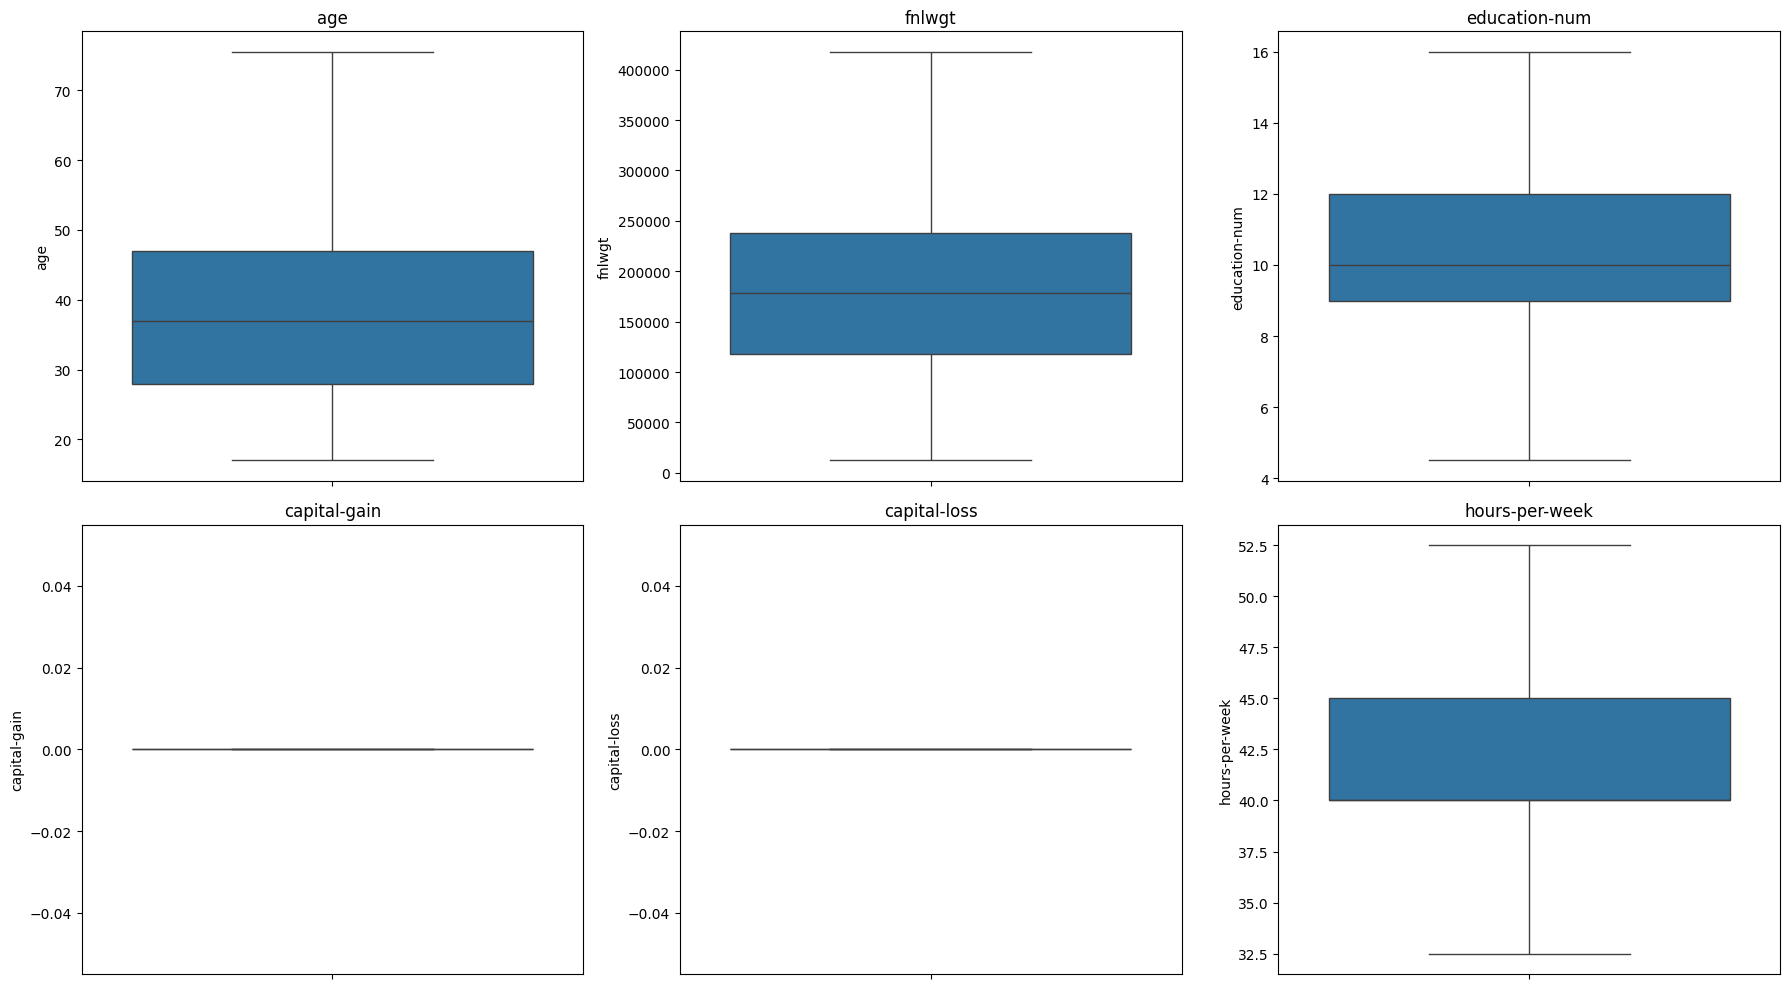

In [25]:
plt.figure(figsize=(18,10))

for i, col in enumerate(num_cols):
    plt.subplot(2,3,i+1)
    sns.boxplot(y=adult[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [26]:
adult_original = adult.copy()

In [27]:
adult = adult.drop("income", axis=1)

In [28]:
adult.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,39.0,State-gov,77516,Bachelors,13.0,Never-married,Adm-clerical,Not-in-family,White,Male,0,0,40.0,United-States
1,50.0,Self-emp-not-inc,83311,Bachelors,13.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,32.5,United-States
2,38.0,Private,215646,HS-grad,9.0,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40.0,United-States
3,53.0,Private,234721,11th,7.0,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40.0,United-States
4,28.0,Private,338409,Bachelors,13.0,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba


In [29]:
cat_cols = adult.select_dtypes(include='object').columns
cat_cols

Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country'],
      dtype='object')

In [30]:
adult["education"].value_counts()

,count
education,
HS-grad,15780
Some-college,10874
Bachelors,8021
Masters,2657
Assoc-voc,2060
11th,1812
Assoc-acdm,1601
10th,1389
7th-8th,955


In [31]:
adult["education-num"].value_counts()

,count
education-num,
9.0,15780
10.0,10874
13.0,8021
14.0,2657
11.0,2060
7.0,1812
4.5,1792
12.0,1601
6.0,1389


In [32]:
adult.drop('education-num', axis=1, inplace=True)

In [33]:
education_mapping = {
    'Preschool': 1,
    '1st-4th': 2,
    '5th-6th': 3,
    '7th-8th': 4,
    '9th': 5,
    '10th': 6,
    '11th': 7,
    '12th': 8,
    'HS-grad': 9,
    'Some-college': 10,
    'Assoc-voc': 11,
    'Assoc-acdm': 12,
    'Bachelors': 13,
    'Masters': 14,
    'Prof-school': 15,
    'Doctorate': 16
}
adult['education'] = adult['education'].map(education_mapping)

In [34]:
adult["relationship"].value_counts()

,count
relationship,
Husband,19714
Not-in-family,12572
Own-child,7578
Unmarried,5125
Wife,2331
Other-relative,1506


In [35]:
adult["occupation"].value_counts()

,count
occupation,
Prof-specialty,10966
Craft-repair,5790
Exec-managerial,5770
Adm-clerical,5328
Sales,5231
Other-service,4654
Machine-op-inspct,2872
Transport-moving,2238
Handlers-cleaners,1976


In [36]:
adult["marital-status"].value_counts()

,count
marital-status,
Married-civ-spouse,22377
Never-married,16105
Divorced,6631
Separated,1530
Widowed,1518
Married-spouse-absent,628
Married-AF-spouse,37


In [37]:
adult["race"].value_counts()

,count
race,
White,41747
Black,4685
Asian-Pac-Islander,1518
Amer-Indian-Eskimo,470
Other,406


In [38]:
adult["workclass"].value_counts()

,count
workclass,
Private,37330
Self-emp-not-inc,3649
Local-gov,2973
State-gov,1877
Self-emp-inc,1624
Federal-gov,1346
Without-pay,18
Never-worked,9


In [39]:
adult["native-country"].value_counts()

,count
native-country,
United-States,44869
Mexico,906
Philippines,282
Germany,194
Puerto-Rico,175
Canada,170
El-Salvador,147
India,143
Cuba,132


In [40]:
adult["marital-status"].value_counts()

,count
marital-status,
Married-civ-spouse,22377
Never-married,16105
Divorced,6631
Separated,1530
Widowed,1518
Married-spouse-absent,628
Married-AF-spouse,37


In [41]:
adult["relationship"].value_counts()

,count
relationship,
Husband,19714
Not-in-family,12572
Own-child,7578
Unmarried,5125
Wife,2331
Other-relative,1506


In [42]:
adult["race"].value_counts()

,count
race,
White,41747
Black,4685
Asian-Pac-Islander,1518
Amer-Indian-Eskimo,470
Other,406


In [43]:

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

adult['sex'] = le.fit_transform(adult['sex'])
adult['native-country'] = le.fit_transform(adult['native-country'])
adult["occupation"] = le.fit_transform(adult["occupation"])
adult["workclass"] = le.fit_transform(adult["workclass"])
adult["marital-status"] = le.fit_transform(adult["marital-status"])


In [44]:
onehot_cols = [
    'relationship',
    'race'
]

adult = pd.get_dummies(
    adult,
    columns=onehot_cols,
    prefix={

        'relationship': 're',
        'race': 'ra'
    },
    drop_first=True,
    dtype=int
)

In [45]:
adult.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'marital-status',
       'occupation', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week',
       'native-country', 're_Not-in-family', 're_Other-relative',
       're_Own-child', 're_Unmarried', 're_Wife', 'ra_Asian-Pac-Islander',
       'ra_Black', 'ra_Other', 'ra_White'],
      dtype='object')

In [46]:
adult.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48826 entries, 0 to 48841
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    48826 non-null  float64
 1   workclass              48826 non-null  int64  
 2   fnlwgt                 48826 non-null  int64  
 3   education              48826 non-null  int64  
 4   marital-status         48826 non-null  int64  
 5   occupation             48826 non-null  int64  
 6   sex                    48826 non-null  int64  
 7   capital-gain           48826 non-null  int64  
 8   capital-loss           48826 non-null  int64  
 9   hours-per-week         48826 non-null  float64
 10  native-country         48826 non-null  int64  
 11  re_Not-in-family       48826 non-null  int64  
 12  re_Other-relative      48826 non-null  int64  
 13  re_Own-child           48826 non-null  int64  
 14  re_Unmarried           48826 non-null  int64  
 15  re_Wife

In [47]:
adult.head()

,age,workclass,fnlwgt,education,marital-status,occupation,sex,capital-gain,capital-loss,hours-per-week,native-country,re_Not-in-family,re_Other-relative,re_Own-child,re_Unmarried,re_Wife,ra_Asian-Pac-Islander,ra_Black,ra_Other,ra_White
0,39.0,6,77516,13,4,0,1,0,0,40.0,38,1,0,0,0,0,0,0,0,1
1,50.0,5,83311,13,2,3,1,0,0,32.5,38,0,0,0,0,0,0,0,0,1
2,38.0,3,215646,9,0,5,1,0,0,40.0,38,1,0,0,0,0,0,0,0,1
3,53.0,3,234721,7,2,5,1,0,0,40.0,38,0,0,0,0,0,0,1,0,0
4,28.0,3,338409,13,2,9,0,0,0,40.0,4,0,0,0,0,1,0,1,0,0


In [48]:
adult.shape

(48826, 20)

In [49]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

adult_scaled = scaler.fit_transform(adult)

adult_scaled = pd.DataFrame(adult_scaled, columns=adult.columns)

adult_scaled.head()

,age,workclass,fnlwgt,education,marital-status,occupation,sex,capital-gain,capital-loss,hours-per-week,native-country,re_Not-in-family,re_Other-relative,re_Own-child,re_Unmarried,re_Wife,ra_Asian-Pac-Islander,ra_Black,ra_Other,ra_White
0,0.035123,2.689325,-1.146152,1.136533,0.916280,-1.607341,0.704165,0.0,0.0,-0.187370,0.253152,1.698149,-0.178398,-0.428623,-0.342453,-0.223907,-0.17913,-0.325787,-0.091569,0.411788
1,0.864064,1.763610,-1.085355,1.136533,-0.410262,-0.841717,0.704165,0.0,0.0,-1.430414,0.253152,-0.588876,-0.178398,-0.428623,-0.342453,-0.223907,-0.17913,-0.325787,-0.091569,0.411788
2,-0.040236,-0.087820,0.303009,-0.419444,-1.736803,-0.331301,0.704165,0.0,0.0,-0.187370,0.253152,1.698149,-0.178398,-0.428623,-0.342453,-0.223907,-0.17913,-0.325787,-0.091569,0.411788
3,1.090139,-0.087820,0.503130,-1.197432,-0.410262,-0.331301,0.704165,0.0,0.0,-0.187370,0.253152,-0.588876,-0.178398,-0.428623,-0.342453,-0.223907,-0.17913,3.069490,-0.091569,-2.428436
4,-0.793819,-0.087820,1.590950,1.136533,-0.410262,0.689531,-1.420121,0.0,0.0,-0.187370,-5.513621,-0.588876,-0.178398,-0.428623,-0.342453,4.466136,-0.17913,3.069490,-0.091569,-2.428436


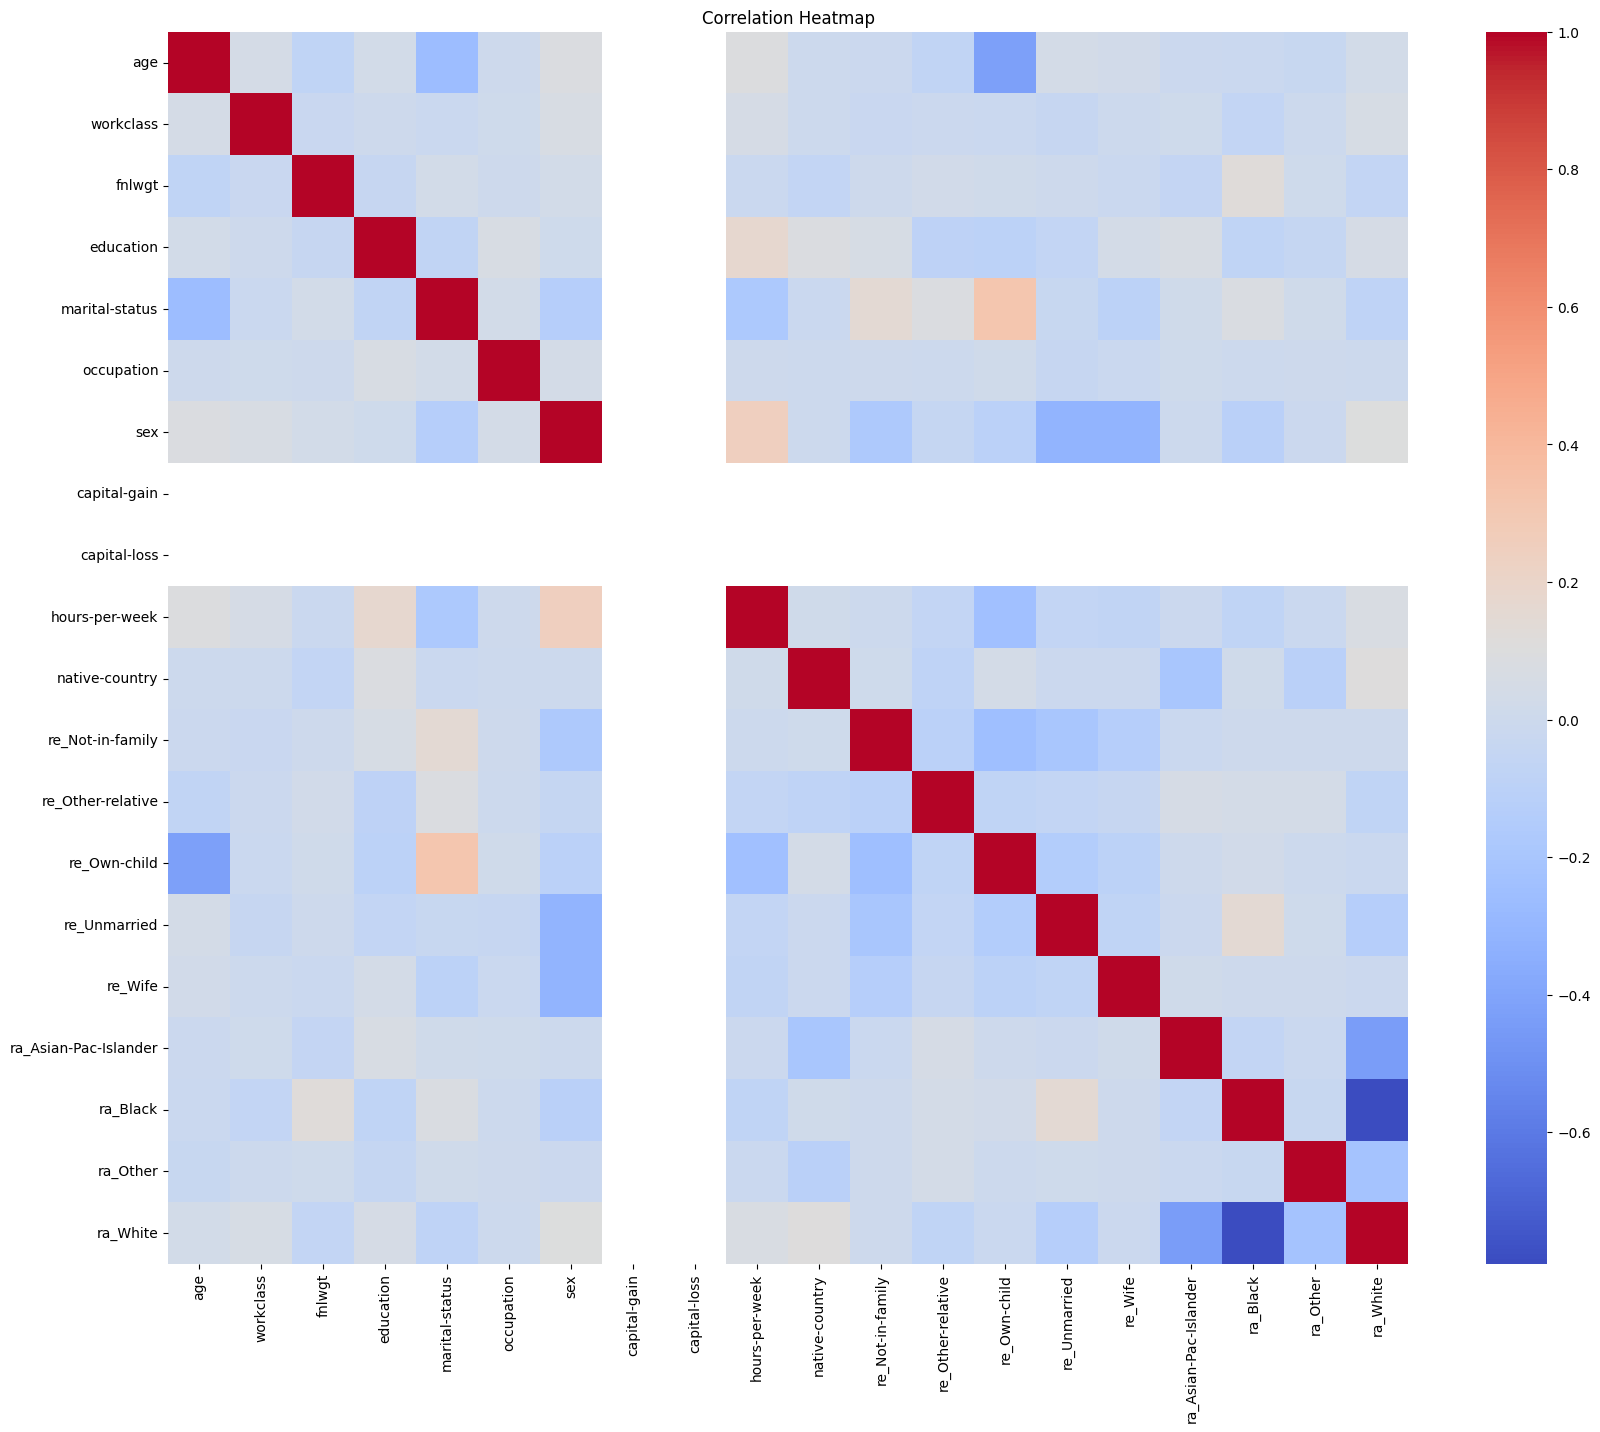

In [50]:
plt.figure(figsize=(20,16))

sns.heatmap(
    adult_scaled.corr(),
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

In [51]:
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(adult_scaled)
explained = pca.explained_variance_ratio_.cumsum()
print(explained)

[0.12102692 0.2199253  0.30087    0.37222127 0.44211233 0.50718786
 0.5652879  0.62120076 0.67648659 0.73145772 0.78528519 0.83756146
 0.88087223 0.92038823 0.95721065 0.98656695 0.99791614 1.
 1.         1.        ]


In [52]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95, random_state=42)
adult_pca = pca.fit_transform(adult_scaled)

print("Number of components:", pca.n_components_)

Number of components: 15


In [53]:
adult_pca.shape

(48826, 15)

In [54]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1,11):
    model = KMeans(
        n_clusters=i,
        init="k-means++",
        random_state=42,
        n_init=10
    )

    model.fit(adult_pca)

    wcss.append(model.inertia_)

print(wcss)

[841261.8122994556, 746791.7700304873, 685038.0350175835, 634886.1122953565, 580851.84922188, 538097.36512356, 491455.38714633306, 446946.1474896792, 404288.7275910892, 381454.21308725566]


Text(0, 0.5, 'wcss')

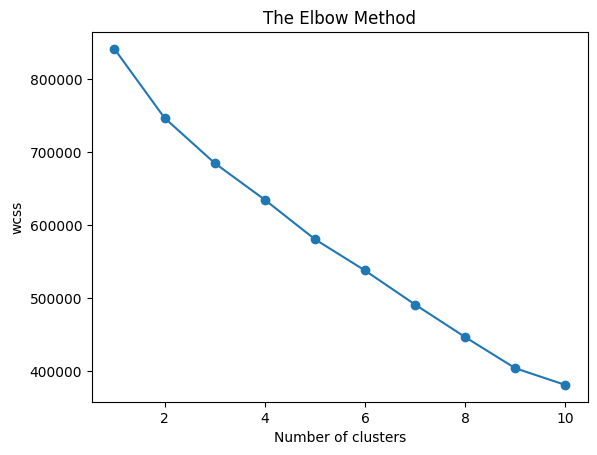

In [55]:
plt.plot(range(1,11),wcss,marker="o")
plt.title("The Elbow Method")
plt.xlabel("Number of clusters")
plt.ylabel("wcss")

In [57]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

scores = []

for i in range(2,11):
    model = KMeans(
        n_clusters=i,
        init="k-means++",
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(adult_pca)

    score = silhouette_score(adult_pca, labels)
    scores.append(score)

    print(f"k={i}: {score:.4f}")

k=2: 0.3147
k=3: 0.1313
k=4: 0.1567
k=5: 0.1660
k=6: 0.1939
k=7: 0.1967
k=8: 0.2302
k=9: 0.2442
k=10: 0.2504


In [58]:
kmeans = KMeans(
    n_clusters=3,
    init="k-means++",
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(adult_pca)

adult["KMeans_Cluster"] = kmeans_labels

In [59]:
adult["KMeans_Cluster"].value_counts()

,count
KMeans_Cluster,
0,26432
1,15652
2,6742


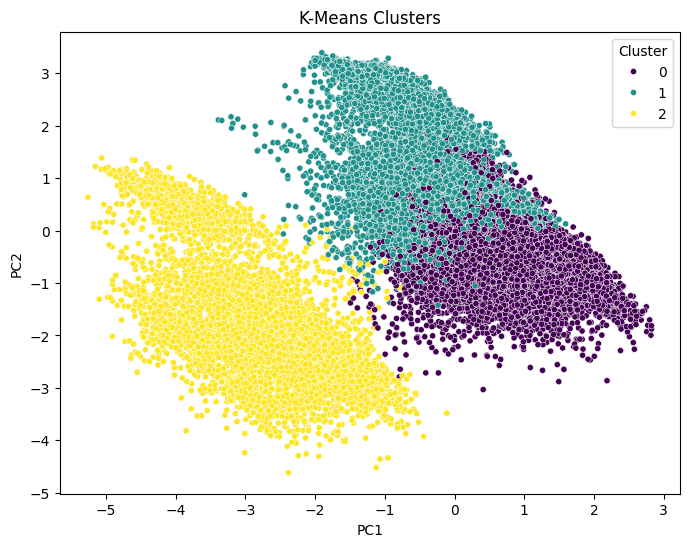

In [60]:
import seaborn as sns
import pandas as pd

plot_df = pd.DataFrame({
    "PC1": adult_pca[:,0],
    "PC2": adult_pca[:,1],
    "Cluster": adult["KMeans_Cluster"]
})

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=plot_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="viridis",
    s=20
)

plt.title("K-Means Clusters")
plt.show()

In [61]:
from sklearn.metrics import silhouette_score

kmeans_score = silhouette_score(adult_pca, kmeans_labels)

print("K-Means Silhouette Score:", kmeans_score)

K-Means Silhouette Score: 0.13132149791266398


clustering

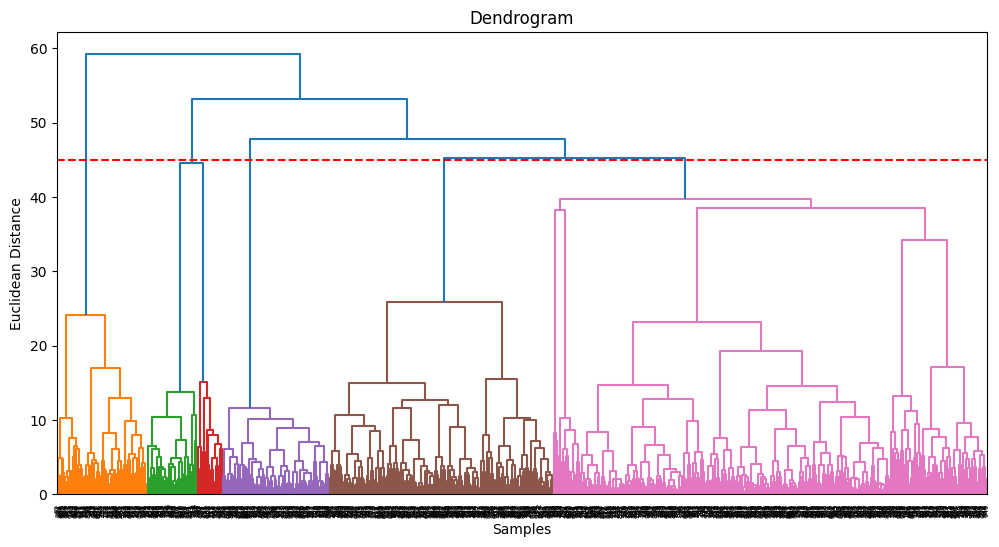

In [62]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# Use a sample for the dendrogram
sample = adult_pca[:1000]

merging = linkage(sample, method="ward")

plt.figure(figsize=(12,6))

dendrogram(merging)

plt.title("Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Euclidean Distance")
plt.axhline(y=45, color="red", linestyle="--")


In [63]:
adult_pca_sample = adult_pca[:5000]

In [65]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(
    n_clusters=3,
    linkage="ward"
)

agg_labels = agg.fit_predict(adult_pca_sample)



In [66]:
adult_sample = adult.iloc[:5000].copy()

adult_sample["Agg_Cluster"] = agg_labels

In [67]:
adult_sample["Agg_Cluster"].value_counts()

,count
Agg_Cluster,
1,3770
0,650
2,580


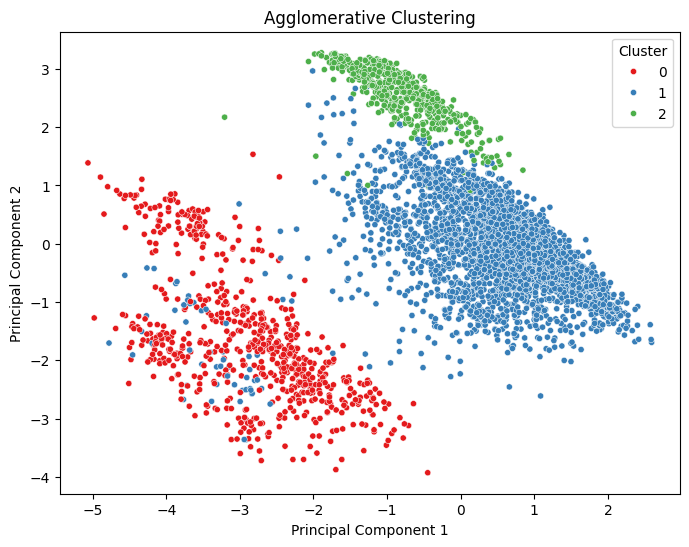

In [71]:
plot_df = pd.DataFrame({
    "PC1": adult_pca_sample[:, 0],
    "PC2": adult_pca_sample[:, 1],
    "Agg_Cluster": agg_labels
})

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=plot_df,
    x="PC1",
    y="PC2",
    hue="Agg_Cluster",
    palette="Set1",
    s=20
)

plt.title("Agglomerative Clustering")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.show()

In [72]:
from sklearn.metrics import silhouette_score

agg_score = silhouette_score(adult_pca_sample, agg_labels)

print("Agglomerative Silhouette Score:", agg_score)

Agglomerative Silhouette Score: 0.10935934971916793


In [73]:
adult.groupby("KMeans_Cluster").mean(numeric_only=True)

,age,workclass,fnlwgt,education,marital-status,occupation,sex,capital-gain,capital-loss,hours-per-week,native-country,re_Not-in-family,re_Other-relative,re_Own-child,re_Unmarried,re_Wife,ra_Asian-Pac-Islander,ra_Black,ra_Other,ra_White
KMeans_Cluster,,,,,,,,,,,,,,,,,,,,
0,43.354778,3.161622,180876.657498,10.297821,1.619930,6.239634,0.795891,0.0,0.0,42.599841,36.868758,0.138128,0.009458,0.013317,0.084216,0.074380,0.000000,0.000000,0.00000,0.992244
1,30.836379,3.045489,189308.874201,9.833951,4.167071,6.372604,0.506900,0.0,0.0,39.132028,36.622349,0.463455,0.053028,0.388449,0.095068,0.000000,0.000000,0.000000,0.00000,0.991567
2,37.504153,2.947790,203937.415752,9.784782,2.938594,6.354791,0.544349,0.0,0.0,40.009641,34.824236,0.247256,0.063186,0.169979,0.209285,0.054138,0.225156,0.694898,0.06022,0.000000


In [76]:
adult_sample.groupby("Agg_Cluster").mean(numeric_only=True)

,age,workclass,fnlwgt,education,marital-status,occupation,sex,capital-gain,capital-loss,hours-per-week,...,re_Not-in-family,re_Other-relative,re_Own-child,re_Unmarried,re_Wife,ra_Asian-Pac-Islander,ra_Black,ra_Other,ra_White,KMeans_Cluster
Agg_Cluster,,,,,,,,,,,,,,,,,,,,,
0,37.520769,2.889231,203351.524615,9.793846,3.052308,6.403077,0.587692,0.0,0.0,39.927692,...,0.276923,0.020000,0.189231,0.220000,0.020000,0.238462,0.712308,0.046154,0.000000,1.996923
1,40.867241,3.119894,185109.502653,10.201857,2.344032,6.301061,0.701592,0.0,0.0,42.007825,...,0.294960,0.035809,0.017772,0.106366,0.061538,0.000000,0.013528,0.000000,0.975332,0.304509
2,24.231034,3.053448,188771.113793,9.605172,3.979310,6.593103,0.593103,0.0,0.0,37.639655,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.991379,0.991379


In [80]:
adult["income"] = adult_original["income"]

pd.crosstab(adult["KMeans_Cluster"], adult["income"])

income,<=50K,<=50K.,>50K,>50K.
KMeans_Cluster,,,,
0,11031,5510,6639,3252
1,9854,5031,512,255
2,3824,1889,690,339


In [81]:
adult_sample["income"] = adult_original["income"].iloc[:5000].values

pd.crosstab(adult_sample["Agg_Cluster"], adult_sample["income"])

income,<=50K,>50K
Agg_Cluster,,
0,549,101
1,2654,1116
2,576,4


## Interpretation & Profiling

### K-Means Clustering

- **Cluster 0:** Contains a higher proportion of individuals earning **>50K**, indicating a relatively high-income group.
- **Cluster 1:** Mostly consists of individuals earning **<=50K**, representing a lower-income group.
- **Cluster 2:** Also dominated by individuals earning **<=50K**, indicating another lower-income group.

### Agglomerative Clustering

- **Cluster 0:** Mainly consists of individuals earning **<=50K**.
- **Cluster 1:** Contains the highest proportion of **>50K** earners, representing a higher-income group.
- **Cluster 2:** Almost entirely consists of individuals earning **<=50K**.

## Policy Suggestions

- **Upskilling Programs:** Target lower-income clusters (K-Means Clusters 1 & 2, Agglomerative Clusters 0 & 2).
- **Tax Reform:** Higher-income clusters (K-Means Cluster 0, Agglomerative Cluster 1) may be considered while designing tax policies.
- **Financial Aid & Inclusion:** Lower-income clusters should receive financial support, employment assistance, and social welfare programs.

## Conclusion

The Adult Income dataset was preprocessed and reduced using PCA before applying K-Means and Agglomerative Clustering. The discovered clusters were compared with the actual income labels for interpretation. The analysis identified both higher-income and lower-income groups, which can help in planning targeted upskilling programs, financial inclusion initiatives, and tax-related policies.